# Übung 8

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### 8.1 Regression für ein Klassifikationsproblem (Teil 3): Feature Engineering (polynomial feature transform)

* **Dies ist eine Fortsetzung von Übung 6.4**, die ich Ihnen der Übersichtlichkeit halber in diese Übung hier ausgelagert habe.
* Bitte schlagen Sie Ihre Jupyter Notebook der Übung 6 auf, und machen sich erneut mit den dortigen Aufgaben vertraut. Kommen Sie anschließend wieder zu dieser Übung zurück.

Wir haben gesehen, dass wir mit unseren linearen Modellen zwar einen großen Teil des vorherigen nicht linear separierbaren Datensatzes korrekt klassifizieren können, dass aber Entscheidungsgeraden nicht zu 100%ig richtigen Klassifikationen führen.

In dieser Übung werden wir eine polynomielle Feature-Transformation nutzen, um nicht linear separierbare Daten zu klassifizieren. Betrachten Sie die folgende Transformation $\Phi: \mathcal{X} \rightarrow \mathcal{Z}$, die unsere Daten aus dem Urbild $\mathcal{X}$ in den sogenannten $\mathcal{Z}$-Raum abbilden. Die Transformation 3ter Ordnung habe ich Ihnen hier einmal aufgeschrieben:

$$\Phi_3(\mathbf{x}) = (1, x_1, x_2, x_1^2, x_1 x_2, x_2^2, x_1^3, x_1^2 x_2, x_1 x_2^2, x_2^3)$$

**Ihre Aufgaben:**

(1) Implementieren Sie $\Phi_3(\mathbf{x})$ in einer Python-Funktion, die die Feature-Vektoren des synthetischen Datensatzes aus Übung 6.4 in den $\mathcal{Z}$-Raum transformiert.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def phi_3(x: np.ndarray) -> np.ndarray:
    x_1 = x[:, 0]
    x_2 = x[:, 1]
    return np.c_[np.ones(x.shape[0]), x_1, x_2, x_1 ** 2, x_1 * x_2, x_2 ** 2, x_1 ** 3, x_1**2 * x_2, x_1 * x_2**2, x_2**3]

(2) Führen Sie mit Ihrem Code aus Übung 6 eine lineare Regression auf dem synthetischen Datensatz durch, wobei Sie die Features benutzen, die Ihnen $\Phi_3$ erzeugt hat. Notieren Sie sich die Zeitdauer, die Ihr Regressionsalgorithmus benötigt.

* Bitte prüfen Sie, ob Ihr übernommener Code aus Übung 6.1 Ihren Features eine zusätzliche "1" (für den Bias-Term) hinzufügt oder nicht. Wie Sie sehen, hat Ihr transformierter Featurevektor aus Schritt (1) schon einen Eintrag "1" für den Bias-Term. Passen Sie also gegebenenfalls Ihren Code so an, dass Sie nur mit einer "1" für den Bias-Term arbeiten und Sie somit nicht irrtümlich zwei Einser-Einträge in Ihren Vektoren stehen haben.

In [3]:
import math


def make_shifted_circle(N: int, r: float, b: float, d: float, shuffle_arrays=True) -> tuple[np.ndarray, np.ndarray]:
    vert_dist = d
    horiz_dist = r + b/2.0
    angles_neg = np.random.rand(math.ceil(N/2.0)) * np.pi
    angles_pos = np.random.rand(math.floor(N/2.0)) * -np.pi
    radius_neg = np.random.rand(math.ceil(N/2.0)) * b + r
    radius_pos = np.random.rand(math.floor(N/2.0)) * b + r
    X_neg = np.array([radius_neg * np.cos(angles_neg), radius_neg * np.sin(angles_neg)]).T
    X_pos = np.array([radius_pos * np.cos(angles_pos), radius_pos * np.sin(angles_pos)]).T
    X_pos[:, 0] += horiz_dist
    X_pos[:, 1] -= vert_dist
    y_neg = np.ones(X_neg.shape[0]) * -1
    y_pos = np.ones(X_pos.shape[0])
    X = np.r_[X_neg, X_pos]
    y = np.r_[y_neg, y_pos]
    if shuffle_arrays:
        argshuffle = np.random.choice(np.arange(N), N)
        X = X[argshuffle]
        y = y[argshuffle]
    return X, y

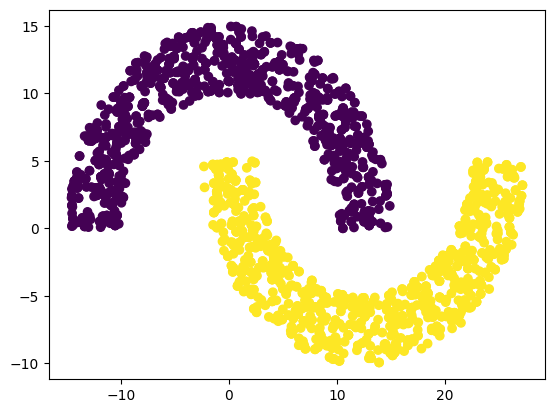

In [4]:
X_insep, y_insep = make_shifted_circle(2000, 10, 5, -5)
plt.scatter(X_insep[:, 0], X_insep[:, 1], c=y_insep)
plt.show()

In [5]:
def lin_reg(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    X = x.copy() #np.column_stack((np.ones(x.shape[0]), x))
    X_pinv = np.linalg.inv(X.T @ X) @ X.T
    return X_pinv @ y


def h(x: np.ndarray, w: np.ndarray):
    return np.sign(x.dot(w))


def g(x_1, w):
    return (w[0] + w[1] * x_1) / (-w[2])

In [6]:
X_transformed = phi_3(X_insep)

In [7]:
%%time

w_lin = lin_reg(X_transformed, y_insep)

CPU times: total: 0 ns
Wall time: 464 μs


Etwa 400 Microsekunden

(3) Ermitteln Sie den Klassifikationsfehler $E_\text{in}$ für Ihre finale Hypothese.

In [8]:
e_in_lin = (h(X_transformed, w_lin) != y_insep).sum() / y_insep.shape[0]
print(f"In-Sample Fehler: {e_in_lin}")

In-Sample Fehler: 0.0105


(4) Visualisieren Sie die Datenpunkte mit Ihren Labels in einem Scatterplot. Visualisieren Sie dazu die Klassifikationskurve, die durch Ihre finale Hypothese und $\Phi_3$ definiert wird.

* Wichtiger Hinweis: In den vorherigen Aufgaben haben Sie die explizite Form von Klassifikationsgeraden hergeleitet und darüber eine einfache Visualisierung der Klassifikationsgrenze erreicht. Dies ist nach einer nichtlinearen Transformation im Allgemeinen so nicht mehr einfach erreichbar. Gehen Sie stattdessen zur Visualisierung der Klassifikationsgrenze wie folgt vor:
  1. "Scannen" Sie den Raum $\mathcal{X}$ in äquidistanten Abständen ab, indem Sie Punktpaare $(x_1, x_2)$ definieren, die wie ein Gitter im Raum $\mathcal{X}$ liegen.
  2. Für jedes der Punktepaare $\mathbf{x} = (x_1, x_2)^\text{T}$ bestimmen Sie $(\mathbf{w}^\text{T}\cdot\Phi_3(\mathbf{x}))$. Dort, wo dieses Skalarprodukt den Wert $0$ annimmt, befindet sich die gesuchte Entscheidungsgrenze, denn ein Datenpunkt $\mathbf{x}^*$ wird als Klasse "+" bzw "-" klassifiziert, je nachdem welches Vorzeichen das Skalarprodukt $(\mathbf{w}^\text{T}\cdot\Phi_3(\mathbf{x^*}))$ annimmt.
  3. Sie können die Entscheidungsgrenze nun auf unterschiedlichen Wegen visualisieren. Der erste Vorschlag sollte Ihnen relativ einfach fallen, da Sie die benötigten Funktionen bereits kennen. Dafür benötigt er aber ein ausreichend feines "Grid" in Schritt (1), was zu erhöhter Rechenzeit führt. Die darauf folgenden Vorschläge nutzen Funktionen von matplotlib, die Ihnen eventuell noch nicht bekannt sind. Sie bieten eine sehr einfache und effiziente Möglichkeit Entscheidungsgrenzen und -flächen zu zeichnen.
     * Vorschlag 1: Durchsuchen Sie das in Schritt (1) erzeugte "Grid" nach den Punkten, die einen Werte nahe $0$ erreichen. Diese Punkte könnten Sie dann zum Beispiel durch ein `plt.scatter` in Ihren Graphen einzeichnen.
     * Vorschlag 2: Nutzen Sie die Funktion `plt.contour`, um die Entscheidungsgrenze einzuzeichnen (Hinweis: setzen Sie den Parameter `levels=1`). Eine Demonstration der Funktion finden Sie unter anderem [hier](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html).
     * Vorschlag 3: Nutzen Sie die Funktion `plt.contourf`, mit der Sie die Entscheidungsflächen einzeichnen können (Hinweis: setzen Sie auch hier den Parameter `levels=1`; über die Parameter `colors` und `alpha` können Sie die Farben der Flächen steuern). Falls Sie Hilfe bei der Nutzung der Funktion benötigen, schauen Sie sich die beiden Demonstrationen [hier](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html) und [hier](https://matplotlib.org/stable/gallery/images_contours_and_fields/contourf_demo.html) an.

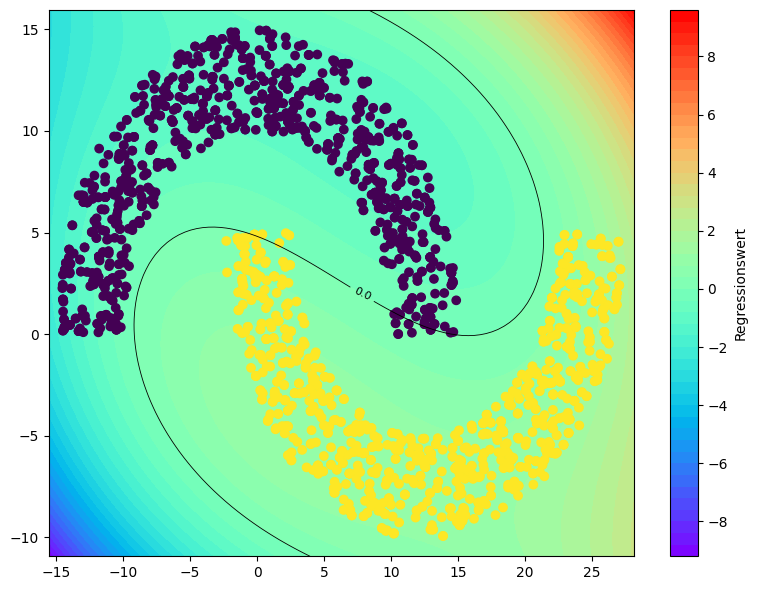

In [9]:
x_space = np.linspace(np.min(X_insep[:, 0]) - 1, np.max(X_insep[:, 0]) + 1, 100)
y_space = np.linspace(np.min(X_insep[:, 1]) - 1, np.max(X_insep[:, 1]) + 1, 100)
x_grid, y_grid = np.meshgrid(x_space, y_space)
X_values = np.c_[x_grid.ravel(), y_grid.ravel()]
X_values_transformed = phi_3(X_values)

z_grid = (X_values_transformed @ w_lin).reshape(100, 100)

plt.figure(figsize=(8, 6))
cf = plt.contourf(x_grid, y_grid, z_grid, levels=60, cmap='rainbow')
cs = plt.contour(x_grid, y_grid, z_grid, levels=1, colors='k', linewidths=0.6)
plt.scatter(X_insep[:, 0], X_insep[:, 1], c=y_insep)

plt.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
plt.colorbar(cf, label='Regressionswert')
plt.tight_layout()
plt.show()

(5) Optional: Wiederholen Sie Schritte 2-4 mit dem Pocket-Algorithmus. Wählen Sie die Iterationszahl $T$ mit Bedacht, denn durch die größere Anzahl an Features im $\mathcal{Z}$-Raum wird sich die Ausführungsdauer deutlich erhöhen. Ermitteln Sie die Ausführungsdauern erst anhand kleiner Werte von $T$ und stellen Sie dann $T$ so ein, dass Ihre Rechnung innerhalb von 15-30 Minuten terminiert. Visualisieren Sie die Kurve der finalen Hypothese; notieren Sie die Ausführungszeit und den $E_\text{in}$-Fehler. Vergleichen Sie lineare Regression und Pocket hinsichtlich ihrer Ausführungsdauern und erzielten In-Sample-Fehler (1-3 Sätze).

Zwei hilfreiche Hinweise:

1. Um die Rechenzeit zu reduzieren, optimieren Sie Ihre Implementierung des Pocket-Algorithmus leicht: Wählen Sie unter den falsch klassifizierten Datenpunkten jeweils **zufällig** einen Punkt aus, für den Sie das Gewichtsupdate durchführen.

2. Falls Sie in der vorigen Aufgabe die Entscheidungsgrenze mit der `scatter`-Funktion eingezeichnet haben, sollten Sie für die Visualisierung der Entscheidungsgrenze in dieser Aufgabe Ihr Vorgehen leicht abwandeln, um Rechenzeit zu sparen. Sie scannen, wie üblich, Ihr Gitter mit möglichen Punkten ab und erhalten jeweils $|\mathbf{w}^\text{T}\cdot\Phi_3(\mathbf{x^*})|$. Färben Sie alle Punkte als Entscheidungsgrenze ein, die die kleinsten Werte in dieser Verteilung annehmen (z.B. alle Punkte des 0,2% Perzentils).

In [10]:
def pla_pocket(x: np.ndarray, y: np.ndarray, iterations: int):
    x_stacked = x.copy() #np.hstack((np.ones(((x.shape[0], 1))), x))
    w_best = np.zeros(x_stacked.shape[1])
    w_curr = w_best.copy()
    bools_curr = h(x_stacked, w_best) != y
    err = np.sum(bools_curr) / bools_curr.shape[0]
    i = 0
    while i < iterations and err > 0:
        # Zufaelliges auswaehlen: Nach Tests ist aufgefallen, dass die Laufzeit des Programms etwa doppelt so lang wird, wenn der Index zufällig ausgewählt wird
        #idx = np.random.choice(np.arange(bools_curr.sum()), 1)[0]
        idx = bools_curr.argmax()
        x_k = x_stacked[idx]
        y_k = y[idx]
        w_curr = w_curr + y_k * x_k
        bools_curr = h(x_stacked, w_curr) != y
        err_temp = np.sum(bools_curr) / bools_curr.shape[0]
        if err_temp < err:
            w_best = w_curr.copy()
            err = err_temp
        i += 1
    return w_best

In [11]:
%%time

w_pocket = pla_pocket(X_transformed, y_insep, 1000000)

CPU times: total: 10.3 s
Wall time: 10.3 s


Etwa 12 Sekunden für Hunderttausend Iterationen

In [12]:
e_in = (h(X_transformed, w_pocket) != y_insep).sum() / y_insep.shape[0]
print(f"In-Sample Fehler: {e_in}")

In-Sample Fehler: 0.0


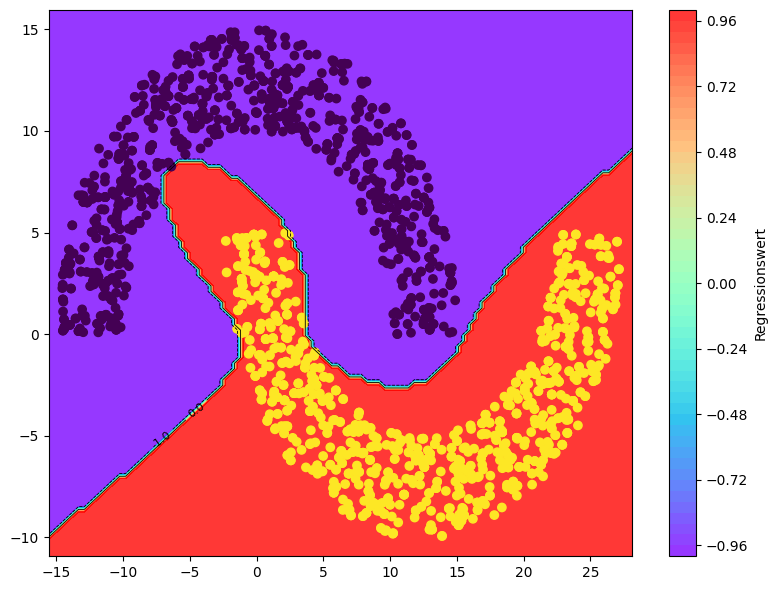

In [13]:
z_grid = h(X_values_transformed, w_pocket).reshape(100, 100)

plt.figure(figsize=(8, 6))
cf = plt.contourf(x_grid, y_grid, z_grid, levels=60, cmap='rainbow', alpha=0.8)
cs = plt.contour(x_grid, y_grid, z_grid, levels=1, colors='k', linewidths=0.6)
plt.scatter(X_insep[:, 0], X_insep[:, 1], c=y_insep)

plt.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
plt.colorbar(cf, label='Regressionswert')
plt.tight_layout()
plt.show()

Damit darf ich Ihnen gratulieren. Sie haben mit dieser Übung eine weitere Methode kennengelernt, um Features zu generieren.

### 8.2 Klassifikation für ein Regressionsproblem
In der Übung 8.1 sowie in den Übungen der Übungseinheit 6 haben wir Klassifikationsprobleme mithilfe der linearen Regression gelöst. In dieser Übung werden wir sehen, dass sich auch Regressionsprobleme als Klassifikationsproblem interpretieren und lösen lassen.

**Ihre Aufgaben**

(1) Führen Sie den unten stehenden Code aus und betrachten Sie den Datensatz. Wir haben vor, eine Regressionsgerade zu finden, die den Datensatz beschreibt.

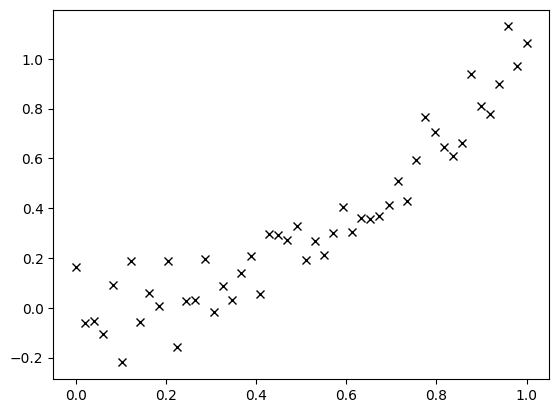

In [14]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# Generate a synthetic data set consisting of 50 data points x with labels y (real numbers).
np.random.seed(1) # fix the state of the random number generator for reproducible results
N = 50 # number of data points
epsilon = np.random.normal(scale=0.1, size=(N,))
x = np.linspace(0, 1, N)
y = x**2 + epsilon

# produce a test figure
plt.plot(x, y, 'kx')

(2) Nutzen Sie Ihren Code aus Übung 6.1 und erhalten Sie mittels linearer Regression eine finale Hypothese, die die Daten beschreibt. Visualisieren Sie die Daten zusammen mit Ihrer finalen Hypothese.

In [15]:
x_stacked = np.c_[np.ones(x.shape[0]), x]
w_lin = lin_reg(x_stacked, y)

In [16]:
def predict(x: np.typing.ArrayLike):
    x = np.array(x)
    X = np.column_stack((np.ones(x.shape[0]), x))
    return X @ w_lin

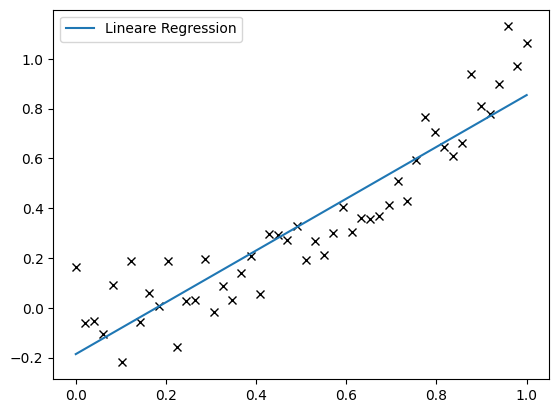

In [17]:
plt.plot(x, y, 'kx')
y_pred = predict(x)
plt.plot(x, y_pred, label="Lineare Regression")
plt.legend()
plt.show()

(3) Berechnen Sie den In-Sample-Fehler $E_\text{in}$, der für unser vorliegendes Regressionsproblem als der Mittelwert über die quadratischen Abweichungen zwischen der Geraden und den Datenpunkten definiert ist (Sie können die Fehlerdefinition gerne in den Vorlesungsfolien nachschlagen).

In [18]:
n = y.shape[0]
e_in = ((y - y_pred)**2).sum() / n
print(e_in)

0.017573702512320023


(4) Erzeugen Sie zwei neue Datensätze, indem Sie den vorliegenden Datensatz verdoppeln und auf der y-Achse nach oben bzw. nach unten verschieben. Formaler: Erzeugen Sie
$$ \mathcal{D}_+ = \begin{pmatrix} x_1\\ y_1 \end{pmatrix} + \mathbf{a}, \ldots, \begin{pmatrix} x_N\\ y_N \end{pmatrix} + \mathbf{a} $$
sowie
$$ \mathcal{D}_- = \begin{pmatrix} x_1\\ y_1 \end{pmatrix} - \mathbf{a}, \ldots, \begin{pmatrix} x_N\\ y_N \end{pmatrix} - \mathbf{a} $$
mit $\mathbf{a} = \begin{pmatrix} 0 \\ 0.3 \end{pmatrix}$.

In [19]:
y_p = y+0.3
y_m = y-0.3

(5) Visualisieren Sie beide Datensätze in einem Scatterplot mit unterschiedlichen Farben. Sie haben durch die Erzeugung der beiden Datensätze aus einem Regressionsproblem ein Klassifikationsproblem gemacht.

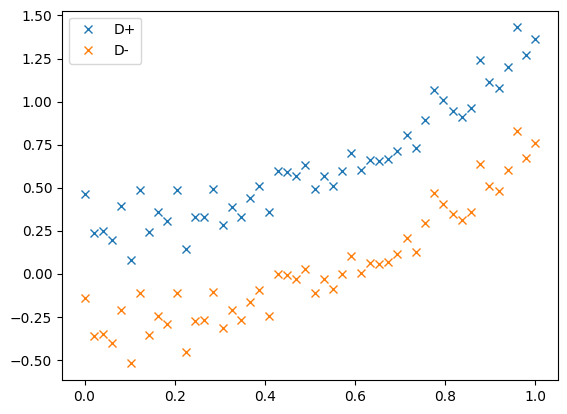

In [20]:
plt.plot(x, y_p, 'x', label="D+")
plt.plot(x, y_m, 'x', label="D-")
plt.legend()
plt.show()

(6) Nutzen Sie den Pocket-Algorithmus mit $T>1000$ Iterationsschritten und erhalten Sie eine finale Hypothese, die $\mathcal{D}_+$ und $\mathcal{D}_-$ voneinander trennt. (Wählen Sie für das Training mit Pocket zwei unterschiedliche Labels, die die Daten jeweils aus $\mathcal{D}_+$ bzw $\mathcal{D}_-$ kodieren.)

In [21]:
ones_p = np.ones(y_p.shape[0])
ones_m = np.ones(y_m.shape[0])
X = np.r_[np.c_[ones_p, x, y_p], np.c_[ones_m, x, y_m]]
labels = np.r_[ones_p, ones_m * -1]
N = labels.shape[0]
argshuffle = np.random.choice(np.arange(N), N)
X = X[argshuffle]
labels = labels[argshuffle]

In [22]:
%%time

w_pocket = pla_pocket(X, labels, 1000000)

CPU times: total: 0 ns
Wall time: 553 μs


(7) Bestimmen Sie den In-Sample Fehler (quadratische Abweichungen) dieser im Schritt 6 ermittelten finalen Hypothese auf den im Schritt 1 betrachteten Daten und geben Sie den Regressionsfehler an.

In [23]:
e_in = (h(X, w_pocket) != labels).sum() / labels.shape[0]
print(f"In-Sample Fehler: {e_in}")

In-Sample Fehler: 0.0


(8) Visualisieren Sie die finalen Hypothesen, die Sie im Schritt 7 und im Schritt 2 gewonnen haben, zusammen mit den Daten in einem Scatterplot. Vergleichen Sie die beiden Ergebnisse (1-3 Sätze).

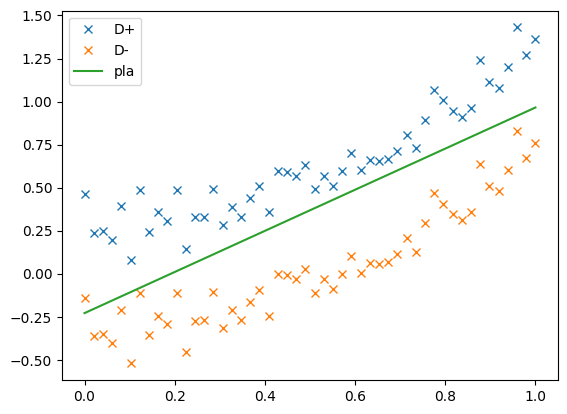

In [24]:
plt.plot(x, y_p, 'x', label="D+")
plt.plot(x, y_m, 'x', label="D-")
plt.plot(x, g(x, w_pocket), label="pla")
plt.legend()
plt.show()

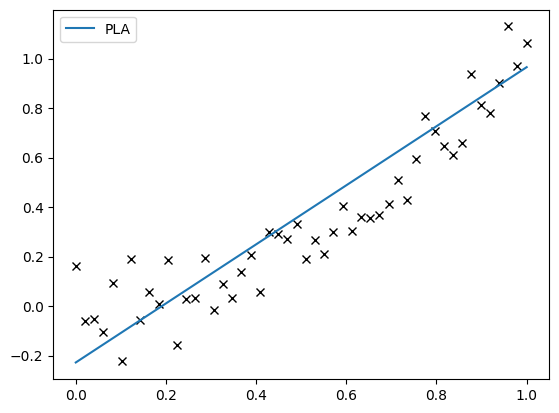

In [25]:
plt.plot(x, y, 'kx')
y_pred = g(x, w_pocket)
plt.plot(x, y_pred, label="PLA")
plt.legend()
plt.show()

### 8.3 Principal Component Analysis (PCA)

In dieser Aufgabe werden wir uns mit der Hauptkomponentenzerlegung (principal component analysis, kurz PCA) beschäftigen. Sie ist eine Methode des unüberwachten Lernens (unsupervised learning).

Wenn Sie sich mit Projekten im Bereich Machine Learning und/oder Data Science beschäftigen, dann wird Ihnen die PCA immer wieder begegnen. Sie ist eine beliebte Methode zur Reduzierung der Anzahl der Merkmale (Features) in einem Lernproblem. Deswegen ist es wichtig, dass Sie verstehen, wie diese Methode funktioniert und wie sie eingesetzt wird.

Wir gehen in zwei Schritten vor. Im ersten Schritt lesen und verstehen Sie das Lernmaterial zum Thema PCA, welches ich Ihnen zur Verfügung gestellt habe (dies passiert in dieser Aufgabe). Im zweiten Schritt (in der nächsten Übung) werden Sie die PCA bei einem Lernproblem anwenden.

**Ihre Aufgaben**

(1) Sie finden die Folien des *Anhangs A* dieser Vorlesung bei Ilias in der Folienliste (Dateiname: ML-1-Anhang-A-v_1_0.pdf). Laden Sie diese Folien und studieren Sie sie. Bearbeiten Sie anschließend die Fragen in den nachfolgenden Aufgabenteilen.

(2) Erläutern Sie in wenigen Sätzen: Was ist der "Fluch der Dimensionalität" und welche Folgen hat er für Machine Learning Projekte?

(3) Die PCA ist ein Verfahren, welches neue Achsen für den Featureraum berechnet. Nach welchen Kriterien ermittelt die PCA diese neuen Achsen?

(4) Betrachten Sie ein Lernproblem mit $N=100$ Datenpunkten, bei der jeder Datenpunkt $D=3$ Features (Merkmale) aufweist. Ihre Datenmatrix $X$ hat also die Gestalt $100\times 3$. Welche Gestalt hat die Kovarianzmatrix $S$, die aus den Daten berechnet wird?

(5) Wir betrachten eine Eigenwertzerlegung der Kovarianzmatrix $S$. Sei $\lambda_1$ der größte Eigenwert und $\mathbf{u}_1$ der zu $\lambda_1$ assoziierte Eigenvektor. Wie können Sie den konkreten Wert, den $\lambda_1$ annimmt, interpretieren? (Welche Größe stellt $\lambda_1$ dar?)

(6) Wie können Sie $\lambda_2$ interpretieren?

(7) Wie können Sie $\mathcal{u}_1$ interpretieren?

(8) Sie betrachten nun die Eigenwertzerlegung einer Kovarianzmatrix $S$ mit den nach Größe absteigend sortierten Eigenwerten $\lambda_1, \ldots, \lambda_D$. Sie haben Ihre Daten in die PCA-Achsen transformiert.

* Wie viele Dimensionen haben Ihre transformierten Features (Merkmale)?
* Wenn Sie eine Dimensionsreduktion vornehmen wollen, müssen Sie Dimensionen "verwerfen". Wie können Sie entscheiden, welche Dimensionen Sie verwerfen wollen?